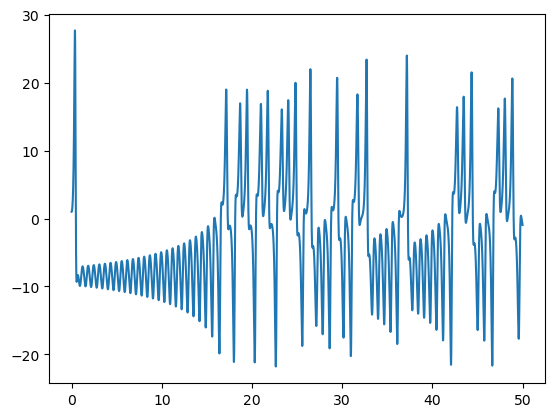

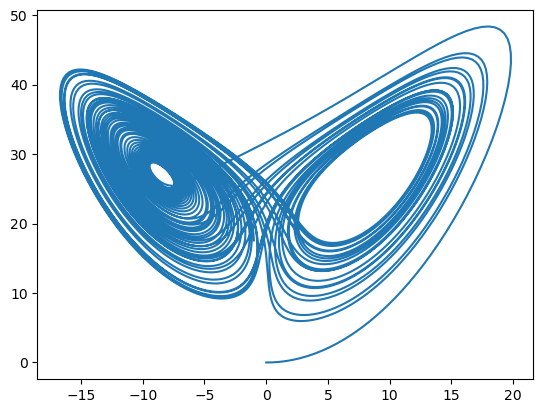

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sigma=10
r=28
b=8/3

t0=0
t_max=50
N=10000
tp=np.linspace(t0,t_max, N)
h=t_max/N

def F(u):
    x, y, z = u
    return np.array([sigma*(y-x), r*x-y-x*z, x*y-b*z], float)

u = np.array([0,1,0], float)

xp=[]
yp=[]
zp=[]

for t in tp:
    x, y, z = u
    xp.append(x)
    yp.append(y)
    zp.append(z)

    k1 = h*F(u)
    k2 = h*F(u+k1/2)
    k3 = h*F(u+k2/2)
    k4 = h*F(u+k3)

    u+=1/6*(k1+2*k2+2*k3+k4)

plt.plot(tp, yp)
plt.show()

plt.plot(xp, zp)
plt.show()

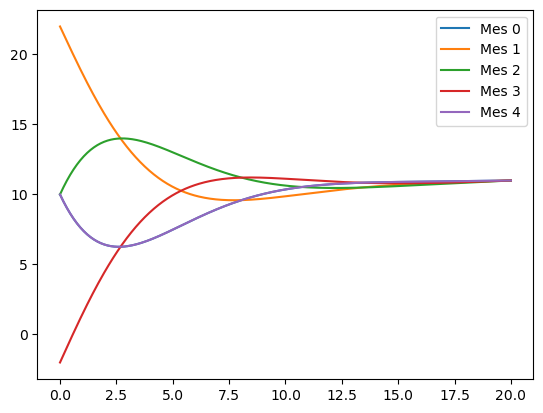

In [4]:
import numpy as np
import matplotlib.pyplot as plt

tau=365
A=10
B=12
D=0.1

# Parte espacial
L=20
N=400
xp=np.linspace(0,L,N)
a=L/N

# Parte temporal
h=0.01
tp=np.arange(0,10*365+h,h)

# Conds. de contorno
T = np.zeros(N, float)
T[-1]=11 # a 20m bajo tierra tenemos T=11ºC = cte.

# Resolución: FTCS

times = (9+np.array([0,0.25,0.5,0.75,1]))*365

for t in tp:
    # Cond. inicial (dependiente del tiempo)
    T[0]=A+B*np.sin(2*np.pi*t/tau)
    T[1:N-1]+=h*D/a**2 * ( T[2:N]-2*T[1:N-1]+T[0:N-2] )
    for i in times:
        if np.abs(t-i)<h/10:
            plt.plot(xp, T, label=f"Mes {np.where(times==i)[0][0]}")
            plt.legend()

plt.show()
